In [4]:
# 04 FORECASTING ANALYSIS - Member 4
# Dataset: monthly_sales_series.csv (60 months net sales)
# Target: net_sales by month
# Models: Baseline + Prophet
# Metrics: MAE, RMSE

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

Loading monthly_sales_series.csv...
Data shape: (60, 1)
            net_sales
month                
2020-03-01   5595.320
2020-04-01  18914.395
2020-05-01  30221.325
2020-06-01  20459.050
2020-07-01  84576.675


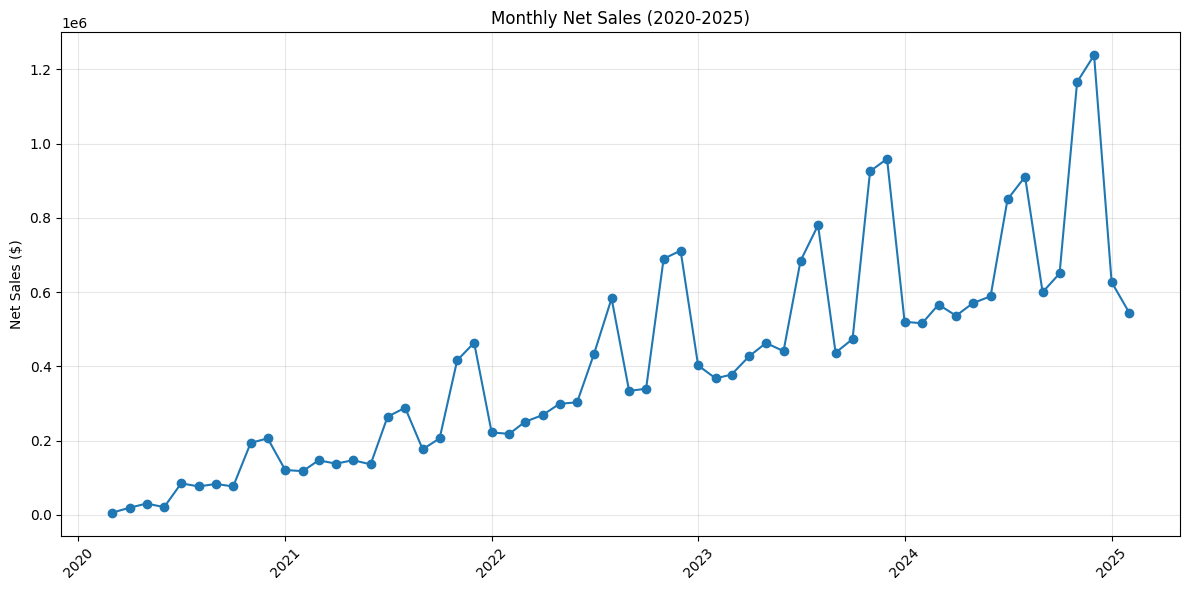

Series shows upward trend with seasonality


In [ ]:
# 1. LOAD AND EXPLORE DATA
import os

print("Loading monthly_sales_series.csv...")

# Using the absolute path to bypass the "Folder Not Found" issues
##file_path = r'C:\Users\ASUS TUF F15\group2-retail-assignment\outputs\tables\monthly_sales_series.csv'

file_path = 'outputs/tables/monthly_sales_series.csv'

df = pd.read_csv(file_path)
df['month'] = pd.to_datetime(df['month'])
df = df.set_index('month').sort_index()

print("Data shape:", df.shape)
print(df.head())

# Plot the series
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['net_sales'], marker='o')
plt.title('Monthly Net Sales (2020-2025)')
plt.ylabel('Net Sales ($)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
##plt.savefig(r'C:\Users\ASUS TUF F15\group2-retail-assignment\outputs\monthly_sales_actual.png', dpi=300, bbox_inches='tight')
plt.savefig('outputs/monthly_sales_actual.png', dpi=300, bbox_inches='tight')
plt.show()
print("Series shows upward trend with seasonality")

In [11]:
# 2. TRAIN-TEST SPLIT (80/20 time-based)
split_idx = int(len(df) * 0.8)  # First 48 months train, last 12 test
train = df.iloc[:split_idx].copy()
test = df.iloc[split_idx:].copy()

print(f"Train: {len(train)} months ({train.index[0]} to {train.index[-1]})")
print(f"Test: {len(test)} months ({test.index[0]} to {test.index[-1]})")


Train: 48 months (2020-03-01 00:00:00 to 2024-02-01 00:00:00)
Test: 12 months (2024-03-01 00:00:00 to 2025-02-01 00:00:00)


In [13]:
# 3. BASELINE: 3-MONTH MOVING AVERAGE
train['ma3_forecast'] = train['net_sales'].rolling(window=3, min_periods=1).mean()
test['ma3_forecast'] = train['ma3_forecast'].iloc[-1]  # Constant forecast

# Evaluate baseline
ma3_mae = mean_absolute_error(test['net_sales'], test['ma3_forecast'])
ma3_rmse = np.sqrt(mean_squared_error(test['net_sales'], test['ma3_forecast']))
print(f"Baseline (3-month MA) - MAE: {ma3_mae:.2f}, RMSE: {ma3_rmse:.2f}")

Baseline (3-month MA) - MAE: 178477.70, RMSE: 247634.68


In [14]:
# 4. PROPHET FORECASTING MODEL
prophet_df = train.reset_index().rename(columns={'month': 'ds', 'net_sales': 'y'})
model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.fit(prophet_df)

future = model.make_future_dataframe(periods=len(test), freq='MS')
forecast = model.predict(future)
prophet_forecast = forecast[forecast['ds'].isin(test.index)]['yhat'].values

prophet_mae = mean_absolute_error(test['net_sales'], prophet_forecast)
prophet_rmse = np.sqrt(mean_squared_error(test['net_sales'], prophet_forecast))
print(f"Prophet Model - MAE: {prophet_mae:.2f}, RMSE: {prophet_rmse:.2f}")

13:17:36 - cmdstanpy - INFO - Chain [1] start processing
13:17:37 - cmdstanpy - INFO - Chain [1] done processing


Prophet Model - MAE: 157954.95, RMSE: 174796.80


In [ ]:
# 5. RESULTS SUMMARY
results = pd.DataFrame({
    'Model': ['3-Month Moving Avg', 'Prophet'],
    'MAE': [ma3_mae, prophet_mae],
    'RMSE': [ma3_rmse, prophet_rmse]
})
print("\nModel Comparison:")
print(results.round(2))

# Save metrics using the absolute path
##results.to_csv(r'C:\Users\ASUS TUF F15\group2-retail-assignment\outputs\forecast_metrics_summary.csv', index=False)
results.to_csv('outputs/forecast_metrics_summary.csv', index=False)


Model Comparison:
                Model        MAE       RMSE
0  3-Month Moving Avg  178477.70  247634.68
1             Prophet  157954.95  174796.80


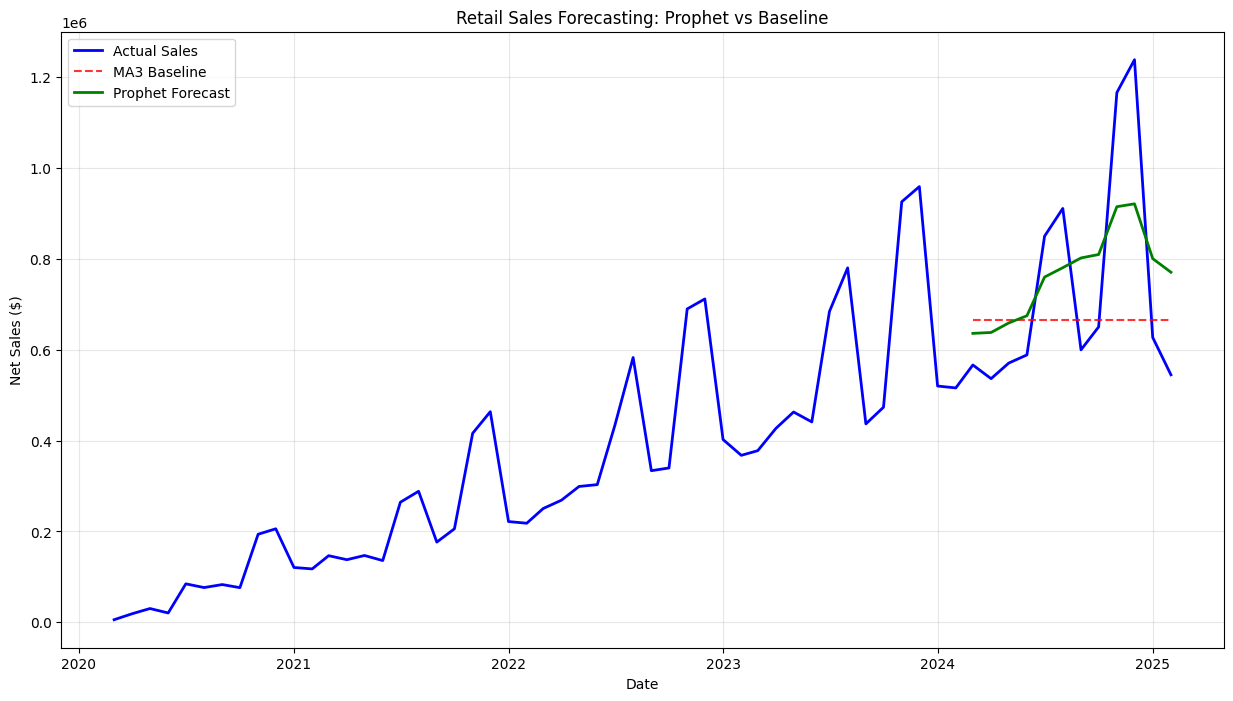

In [ ]:
# 6. VISUALIZATION
plt.figure(figsize=(15, 8))

# Plotting Actual vs Forecasts
plt.plot(df.index, df['net_sales'], 'b-', label='Actual Sales', linewidth=2)
plt.plot(test.index, test['ma3_forecast'], 'r--', label='MA3 Baseline', alpha=0.8)
plt.plot(test.index, prophet_forecast, 'g-', label='Prophet Forecast', linewidth=2)

plt.title('Retail Sales Forecasting: Prophet vs Baseline')
plt.xlabel('Date')
plt.ylabel('Net Sales ($)')
plt.legend()
plt.grid(True, alpha=0.3)

# Save the final comparison plot
##plt.savefig(r'C:\Users\ASUS TUF F15\group2-retail-assignment\outputs\forecast_comparison.png', dpi=300)
plt.savefig('outputs\forecast_comparison.png', dpi=300)
plt.show()